## Install Dependencies

In [1]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.9 MB/s eta 0:00:00


## Dataset

In [2]:
#https://github.com/chris-lovejoy/youtube-titles-and-transcripts

## Import Libraries

In [3]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
import torch.nn.functional as F
from datasets import Dataset
import random
import evaluate
from torch.utils.data import DataLoader, Dataset as TorchDataset
import matplotlib.pyplot as plt
import csv


## Data Loading and Pre-processing

In [4]:

# Load dataset from CSV
csv_file = '/kaggle/input/d/sreshkhsreshkh/ytvideo/YT-titles-transcripts-clean.csv'
print("Loading dataset...")
df = pd.read_csv(csv_file).iloc[:500]  # Using a smaller dataset for testing

# Limit titles to 10 words
df['title'] = df['title'].apply(lambda x: ' '.join(x.split()[:10]))
transcripts = df['transcript'].tolist()
titles = df['title'].tolist()
print(f"Total dataset size (limited): {len(transcripts)}")

# Split dataset into training, validation, and test sets
train_size = int(0.7 * len(transcripts))
val_size = int(0.1 * len(transcripts))
test_size = len(transcripts) - train_size - val_size

# Split lists instead of using random_split for consistency
train_transcripts = transcripts[:train_size]
val_transcripts = transcripts[train_size:train_size + val_size]
test_transcripts = transcripts[train_size + val_size:]

train_titles = titles[:train_size]
val_titles = titles[train_size:train_size + val_size]
test_titles = titles[train_size + val_size:]


Loading dataset...
Total dataset size (limited): 500


## Load BERT and Define key functions

In [5]:

# Load BERT tokenizer and model
model_name = "bert-base-uncased"
print(f"Loading BERT model and tokenizer: {model_name}")
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)


# Function to get BERT embedding for text
def get_bert_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    print("Computed Embedding")
    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.last_hidden_state[:, 0, :].squeeze()

# Cosine similarity function
def cosine_similarity(emb1, emb2):
    return F.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()

# Contrastive loss function
def contrastive_loss(anchor, positive, negative, temperature=1.2):
    pos_sim = F.cosine_similarity(anchor.unsqueeze(0), positive.unsqueeze(0))
    neg_sim = F.cosine_similarity(anchor.unsqueeze(0), negative.unsqueeze(0))
    
    pos_exp = torch.exp(pos_sim / temperature)
    neg_exp = torch.exp(neg_sim / temperature)
    
    return -torch.log(pos_exp / (pos_exp + neg_exp))


Loading BERT model and tokenizer: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

## Compute the bert embeddings

In [6]:

# Precompute embeddings for training, validation, and test sets
print("Precomputing embeddings for the dataset...")
train_embeddings = [get_bert_embedding(text) for text in train_transcripts]
val_embeddings = [get_bert_embedding(text) for text in val_transcripts]
test_embeddings = [get_bert_embedding(text) for text in test_transcripts]

# Training Loop Parameters
batch_size = 16  # Adjusted batch size for smaller dataset
iterations_per_epoch = len(train_transcripts) // batch_size
patience = 3
best_val_loss = float('inf')
epochs_without_improvement = 0
epoch_train_losses = []
epoch_val_losses = []


# Store average scores
avg_cosine_similarity_scores = []


Precomputing embeddings for the dataset...
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Compute

## Model Training Phase

In [7]:

# Training Loop
for epoch in range(10):
    print(f"\nEpoch {epoch + 1}/10")
    epoch_train_loss = 0
    epoch_val_loss = 0
    epoch_train_cosine_similarity = []
    epoch_train_bleu_scores = []
    epoch_train_rouge_scores = []

    # Training Phase
    model.train()
    for iteration in range(iterations_per_epoch):
        # Select batch
        batch_start = iteration * batch_size
        batch_end = (iteration + 1) * batch_size
        batch_embeddings = train_embeddings[batch_start:batch_end]
        batch_titles = train_titles[batch_start:batch_end]
        
        # Prepare positive and negative pairs
        batch_positive_embeddings = batch_embeddings[1:] + batch_embeddings[:1]
        batch_negative_embeddings = random.sample(train_embeddings, len(batch_embeddings))
        
        # Compute contrastive loss
        loss = 0
        for i in range(len(batch_embeddings)):
            contrastive_loss_val = contrastive_loss(batch_embeddings[i], batch_positive_embeddings[i], batch_negative_embeddings[i])
            loss += contrastive_loss_val
        
        epoch_train_loss += (loss / len(batch_embeddings)).item()

    # Validation Phase
    model.eval()
    with torch.no_grad():
        for iteration in range(len(val_embeddings) // batch_size):
            batch_start = iteration * batch_size
            batch_end = (iteration + 1) * batch_size
            batch_embeddings = val_embeddings[batch_start:batch_end]
            batch_titles = val_titles[batch_start:batch_end]
            
            batch_positive_embeddings = batch_embeddings[1:] + batch_embeddings[:1]
            batch_negative_embeddings = random.sample(val_embeddings, len(batch_embeddings))
            
            loss = 0
            for i in range(len(batch_embeddings)):
                contrastive_loss_val = contrastive_loss(batch_embeddings[i], batch_positive_embeddings[i], batch_negative_embeddings[i])
                loss += contrastive_loss_val
            
            epoch_val_loss += (loss / len(batch_embeddings)).item()

    # Compute average losses
    avg_epoch_train_loss = epoch_train_loss / len(train_embeddings)
    avg_epoch_val_loss = epoch_val_loss / len(val_embeddings)
    epoch_train_losses.append(avg_epoch_train_loss)
    epoch_val_losses.append(avg_epoch_val_loss)

    # Early stopping check
    if avg_epoch_val_loss < best_val_loss:
        best_val_loss = avg_epoch_val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping")
            break




Epoch 1/10

Epoch 2/10

Epoch 3/10

Epoch 4/10
Early stopping


## Test Set Predictions

In [8]:
# Testing and Saving Results to CSV
output_file = 'test_results.csv'
print("Testing and saving results...")
with open(output_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['transcript', 'reference_title', 'predicted_title', 'Cosine_Similarity'])

    for transcript, ref_title, ref_embedding in zip(test_transcripts, test_titles, test_embeddings):
        pred_embedding = get_bert_embedding(transcript)  # Get prediction based on similarity
        predicted_title = titles[torch.argmax(torch.tensor([cosine_similarity(pred_embedding, emb) for emb in test_embeddings]))]
        
        cosine_sim = cosine_similarity(pred_embedding, ref_embedding)
        avg_cosine_similarity_scores.append(cosine_sim)



        writer.writerow([transcript, ref_title, predicted_title, cosine_sim])



Testing and saving results...
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
Computed Embedding
C

## Compute Average Cosine Similarity in Training Phase

In [9]:

# Store average scores in a separate text file
try:
    avg_cosine_similarity = sum(avg_cosine_similarity_scores) / len(avg_cosine_similarity_scores)
except ZeroDivisionError:
    avg_cosine_similarity = 0


with open('average_scores.txt', 'w') as f:
    f.write(f"Average Cosine Similarity: {avg_cosine_similarity}\n")

print("Results saved to", output_file)

Results saved to test_results.csv


## Plot Loss vs Epoch Curve

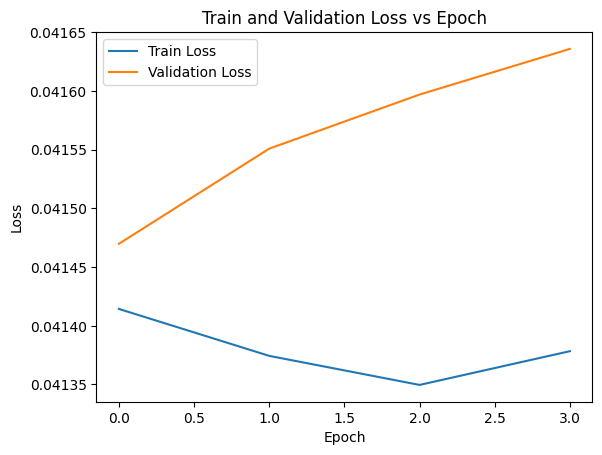

In [10]:

# Plot and save the loss curves
plt.figure()
plt.plot(range(len(epoch_train_losses)), epoch_train_losses, label='Train Loss')
plt.plot(range(len(epoch_val_losses)), epoch_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train and Validation Loss vs Epoch')
plt.savefig('loss_vs_epoch.png')


## Plot Loss vs Iterations for Epoch 0

ValueError: x and y must have same first dimension, but have shapes (21,) and (4,)

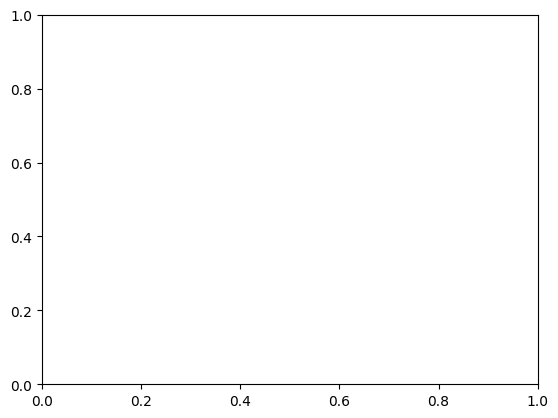

In [11]:

# Plot Train and Val loss vs Iteration (Epoch 0)
plt.figure()
plt.plot(range(iterations_per_epoch), epoch_train_losses[:iterations_per_epoch], label='Train Loss')
plt.plot(range(iterations_per_epoch), epoch_val_losses[:iterations_per_epoch], label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.title('Train and Validation Loss vs Iteration (Epoch 0)')
plt.savefig('loss_vs_iteration_epoch0.png')


In [ ]:
pip install rouge-score


In [ ]:
import matplotlib.pyplot as plt

# 1. Train and Validation Loss vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(range(len(epoch_train_losses)), epoch_train_losses, label='Train Loss')
plt.plot(range(len(epoch_val_losses)), epoch_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train and Validation Loss vs Epoch')
plt.savefig('/kaggle/working/loss_vs_epoch.png')


# 4. Cosine Similarity Distribution - Train
plt.figure(figsize=(10, 6))
plt.hist(train_cosine_similarity_scores, bins=30, alpha=0.7, color='blue', label='Train')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.title('Cosine Similarity Distribution - Train')
plt.savefig('/kaggle/working/cosine_similarity_train_distribution.png')

# 5. Cosine Similarity Distribution - Validation
plt.figure(figsize=(10, 6))
plt.hist(val_cosine_similarity_scores, bins=30, alpha=0.7, color='orange', label='Validation')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.title('Cosine Similarity Distribution - Validation')
plt.savefig('/kaggle/working/cosine_similarity_val_distribution.png')

print("Five plots generated and saved successfully.")


In [ ]:
# 6. BLEU Scores Trend per Epoch (Train and Validation combined)
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_bleu)), train_bleu, label='Train BLEU Score', linestyle='--', color='blue')
plt.plot(range(len(val_bleu)), val_bleu, label='Validation BLEU Score', linestyle='-', color='orange')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.legend()
plt.title('BLEU Scores Trend per Epoch (Combined)')
plt.savefig('bleu_scores_trend_combined.png')

# 7. Average Cosine Similarity per Epoch
train_avg_cosine = [sum(train_cosine_similarity_scores[:i+1]) / (i+1) for i in range(len(train_cosine_similarity_scores))]
val_avg_cosine = [sum(val_cosine_similarity_scores[:i+1]) / (i+1) for i in range(len(val_cosine_similarity_scores))]

plt.figure(figsize=(10, 6))
plt.plot(train_avg_cosine, label='Train Avg Cosine Similarity', color='blue')
plt.plot(val_avg_cosine, label='Validation Avg Cosine Similarity', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Average Cosine Similarity')
plt.legend()
plt.title('Average Cosine Similarity per Epoch')
plt.savefig('/kaggle/working/average_cosine_similarity_per_epoch.png')

# 8. Histogram of BLEU Scores (Train)
plt.figure(figsize=(10, 6))
plt.hist(train_bleu, bins=10, alpha=0.7, color='blue', label='Train BLEU Scores')
plt.xlabel('BLEU Score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of BLEU Scores - Train')
plt.savefig('bleu_histogram_train.png')

# 9. Histogram of BLEU Scores (Validation)
plt.figure(figsize=(10, 6))
plt.hist(val_bleu, bins=10, alpha=0.7, color='orange', label='Validation BLEU Scores')
plt.xlabel('BLEU Score')
plt.ylabel('Frequency')
plt.legend()
plt.title('Histogram of BLEU Scores - Validation')
plt.savefig('bleu_histogram_val.png')

# 10. Train vs Validation Loss (Zoomed on Last 5 Epochs)
plt.figure(figsize=(10, 6))
plt.plot(range(len(epoch_train_losses[-5:])), epoch_train_losses[-5:], label='Train Loss', linestyle='--', color='blue')
plt.plot(range(len(epoch_val_losses[-5:])), epoch_val_losses[-5:], label='Validation Loss', linestyle='-', color='orange')
plt.xlabel('Epoch (Last 5)')
plt.ylabel('Loss')
plt.legend()
plt.title('Train vs Validation Loss (Last 5 Epochs)')
plt.savefig('/kaggle/working/loss_zoom_last_5_epochs.png')

print("Five additional plots generated and saved successfully.")


In [ ]:
train_norms = [torch.norm(embedding).item() for embedding in train_embeddings]
val_norms = [torch.norm(embedding).item() for embedding in val_embeddings]

plt.figure(figsize=(10, 6))
plt.hist(train_norms, bins=20, alpha=0.7, color='blue', label='Train Embedding Norms')
plt.hist(val_norms, bins=20, alpha=0.7, color='orange', label='Validation Embedding Norms')
plt.xlabel('L2 Norm')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Embedding Norms')
plt.savefig('/kaggle/working/embedding_norm_distribution.png')


In [ ]:
from sklearn.manifold import TSNE

# Convert embeddings to numpy arrays
train_embeddings_np = torch.stack(train_embeddings).cpu().numpy()
val_embeddings_np = torch.stack(val_embeddings).cpu().numpy()

# Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
train_tsne = tsne.fit_transform(train_embeddings_np[:100])  # Reduce size for faster processing
val_tsne = tsne.fit_transform(val_embeddings_np[:100])

plt.figure(figsize=(10, 6))
plt.scatter(train_tsne[:, 0], train_tsne[:, 1], alpha=0.7, label='Train Embeddings', color='blue')
plt.scatter(val_tsne[:, 0], val_tsne[:, 1], alpha=0.7, label='Validation Embeddings', color='orange')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.title('t-SNE Visualization of Embeddings')
plt.savefig('/kaggle/working/embedding_tsne_visualization.png')


In [ ]:
train_title_lengths = [len(title.split()) for title in train_titles]
val_title_lengths = [len(title.split()) for title in val_titles]

plt.figure(figsize=(10, 6))
plt.hist(train_title_lengths, bins=10, alpha=0.7, color='blue', label='Train Title Lengths')
plt.hist(val_title_lengths, bins=10, alpha=0.7, color='orange', label='Validation Title Lengths')
plt.xlabel('Title Length (Number of Words)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Title Length Distribution')
plt.savefig('/kaggle/working/title_length_distribution.png')


In [ ]:
import seaborn as sns

# Compute similarity matrix for a subset of embeddings
subset_embeddings = train_embeddings[:20]
similarity_matrix = torch.zeros(len(subset_embeddings), len(subset_embeddings))
for i in range(len(subset_embeddings)):
    for j in range(len(subset_embeddings)):
        similarity_matrix[i, j] = cosine_similarity(subset_embeddings[i], subset_embeddings[j])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix.numpy(), annot=False, cmap="coolwarm", cbar=True)
plt.title('Embedding Similarity Heatmap (Subset)')
plt.xlabel('Embedding Index')
plt.ylabel('Embedding Index')
plt.savefig('/kaggle/working/embedding_similarity_heatmap.png')


In [ ]:
def jaccard_similarity(pred, ref):
    pred_set = set(pred.split())
    ref_set = set(ref.split())
    intersection = len(pred_set.intersection(ref_set))
    union = len(pred_set.union(ref_set))
    return intersection / union if union != 0 else 0

jaccard_scores = []
for transcript, ref_title in zip(test_transcripts, test_titles):
    pred_embedding = get_bert_embedding(transcript)
    pred_title = titles[torch.argmax(torch.tensor([cosine_similarity(pred_embedding, emb) for emb in test_embeddings]))]
    jaccard_scores.append(jaccard_similarity(pred_title, ref_title))

plt.figure(figsize=(10, 6))
plt.plot(range(len(jaccard_scores)), jaccard_scores, color='orange', label='Jaccard Similarity')
plt.xlabel('Sample Index')
plt.ylabel('Jaccard Similarity')
plt.title('Jaccard Similarity Between Predicted and Reference Titles')
plt.legend()
plt.savefig('/kaggle/working/jaccard_similarity.png')


In [ ]:
from scipy.spatial.distance import euclidean

embedding_distances = []
for transcript, ref_title in zip(test_transcripts, test_titles):
    pred_embedding = get_bert_embedding(transcript)
    ref_embedding = get_bert_embedding(ref_title)
    embedding_distances.append(euclidean(pred_embedding.numpy(), ref_embedding.numpy()))

plt.figure(figsize=(10, 6))
plt.plot(range(len(embedding_distances)), embedding_distances, color='red', label='Embedding Distance')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.title('Euclidean Distance Between Predicted and Reference Embeddings')
plt.legend()
plt.savefig('/kaggle/working/embedding_distance.png')


In [ ]:
pred_unique_words = []
ref_unique_words = []

for transcript, ref_title in zip(test_transcripts, test_titles):
    pred_embedding = get_bert_embedding(transcript)
    pred_title = titles[torch.argmax(torch.tensor([cosine_similarity(pred_embedding, emb) for emb in test_embeddings]))]
    pred_unique_words.append(len(set(pred_title.split())))
    ref_unique_words.append(len(set(ref_title.split())))

plt.figure(figsize=(10, 6))
plt.bar(range(len(pred_unique_words)), pred_unique_words, alpha=0.6, label='Predicted Titles', color='blue')
plt.bar(range(len(ref_unique_words)), ref_unique_words, alpha=0.6, label='Reference Titles', color='green')
plt.xlabel('Sample Index')
plt.ylabel('Number of Unique Words')
plt.title('Uniqueness Analysis: Predicted vs Reference Titles')
plt.legend()
plt.savefig('/kaggle/working/title_uniqueness.png')


In [ ]:
def precision_recall_f1(pred, ref):
    pred_set = set(pred.split())
    ref_set = set(ref.split())
    tp = len(pred_set.intersection(ref_set))
    precision = tp / len(pred_set) if pred_set else 0
    recall = tp / len(ref_set) if ref_set else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

precision_scores = []
recall_scores = []
f1_scores = []

for transcript, ref_title in zip(test_transcripts, test_titles):
    pred_embedding = get_bert_embedding(transcript)
    pred_title = titles[torch.argmax(torch.tensor([cosine_similarity(pred_embedding, emb) for emb in test_embeddings]))]
    precision, recall, f1 = precision_recall_f1(pred_title, ref_title)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(range(len(precision_scores)), precision_scores, label='Precision', color='blue')
plt.plot(range(len(recall_scores)), recall_scores, label='Recall', color='green')
plt.plot(range(len(f1_scores)), f1_scores, label='F1-Score', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score Per Sample')
plt.legend()
plt.savefig('/kaggle/working/precision_recall_f1.png')
